                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.753247   0.649123  0.672727  0.660714
1        Random Forest  0.753247   0.654545  0.654545  0.654545
2                  KNN  0.694805   0.583333  0.509091  0.543689
3                  SVM  0.733766   0.645833  0.563636  0.601942
4    Gradient Boosting  0.746753   0.637931  0.672727  0.654867


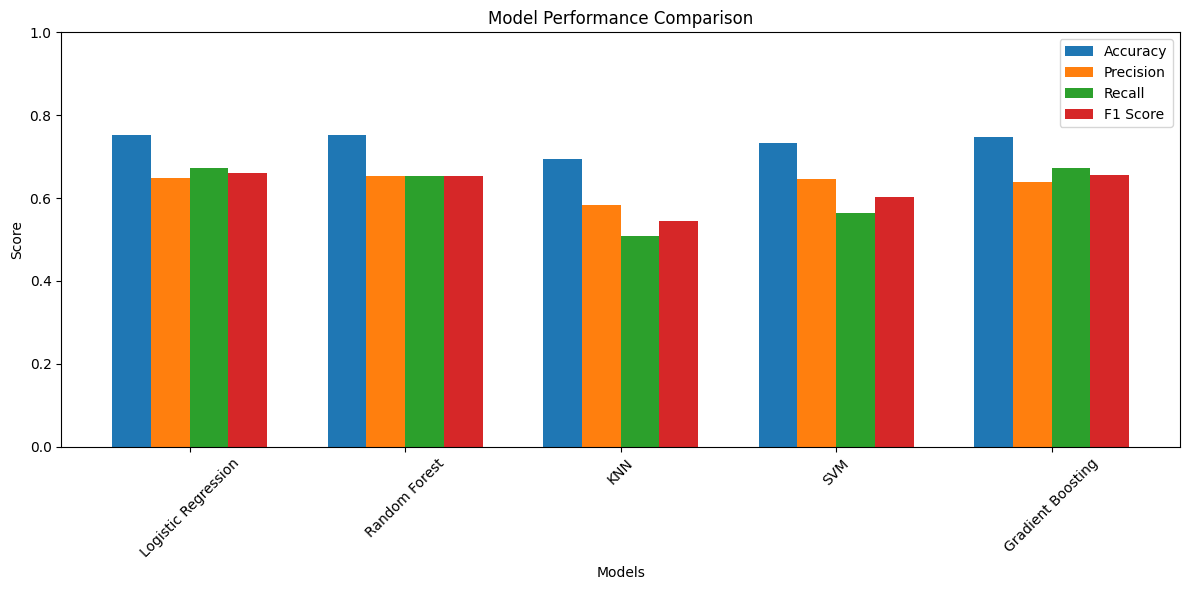

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
import numpy as np


# Loading data

df = pd.read_csv("https://raw.githubusercontent.com/MMShed/DiabetesPredictionModel/refs/heads/main/diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]


# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Scale the data (needed for SVM, KNN, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Choose models

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier()
}

# Train, predict, and evaluate

results = []

for name, model in models.items():
    # Use scaled inputs for models that need it
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])


# Show results

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)


print(results_df)


# PLOT: Compare Accuracy, Precision, Recall, F1


metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

# Convert DataFrame columns (excluding the model names)
metric_values = results_df[metrics].values

# Model names
model_names = results_df["Model"]

# Number of models and metrics
num_models = len(model_names)
num_metrics = len(metrics)

# Bar width and positions
bar_width = 0.18
x = np.arange(num_models)

plt.figure(figsize=(12, 6))

# Plot each metric as a separate bar group
for i, metric in enumerate(metrics):
    plt.bar(
        x + i * bar_width,
        results_df[metric],
        width=bar_width,
        label=metric
    )

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(x + bar_width * (num_metrics - 1) / 2, model_names, rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()